<a href="https://colab.research.google.com/github/GayathriPamarthi20/Car-Price-Prediction-using-Machine-Learning/blob/main/Car_Price_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Results
MAE: 0.58
RMSE: 0.88
R² Score: 0.97


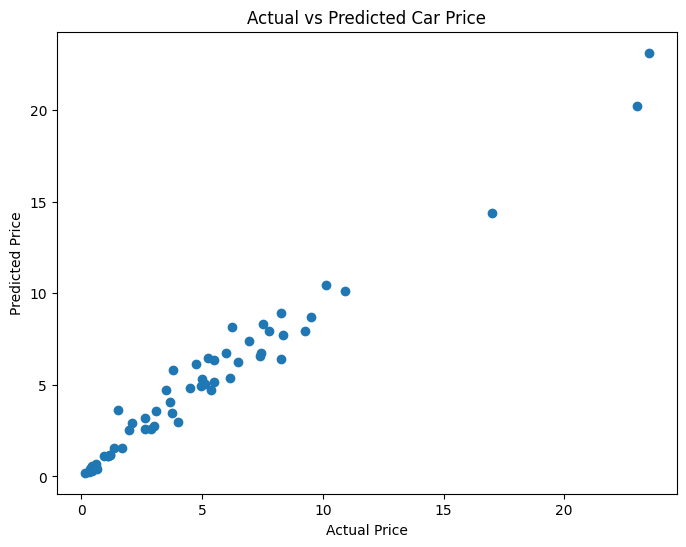


Predicted Car Price:
3.81 Lakhs

Project Completed Successfully!


In [3]:
# ==========================================
# TASK 3: Car Price Prediction
# Google Colab Ready
# ==========================================

# Install libraries
!pip install -q pandas scikit-learn matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------
# Download dataset
# ---------------------------

url = "https://raw.githubusercontent.com/krishnaik06/Car-Price-Prediction/master/car%20data.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
display(df.head())

# ---------------------------
# Preprocessing
# ---------------------------

# Rename target column
df.rename(columns={"Selling_Price":"Price"}, inplace=True)

X = df.drop("Price", axis=1)
y = df["Price"]

# Split numeric & categorical
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        cat_cols
    )
])

# ---------------------------
# Model
# ---------------------------

model = Pipeline([
    ("prep", preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=150,
            random_state=42
        )
    )
])

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
model.fit(
    X_train,
    y_train
)

# Predict
pred = model.predict(
    X_test
)

# ---------------------------
# Evaluation
# ---------------------------

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("\nResults")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

# ---------------------------
# Graph
# ---------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Car Price"
)

plt.show()

# ---------------------------
# Sample Prediction
# ---------------------------

sample = X.iloc[[0]]

result = model.predict(sample)

print("\nPredicted Car Price:")
print(round(result[0],2), "Lakhs")

print("\nProject Completed Successfully!")